# SaaS Product Analytics & Churn Prediction

## 03 — Funnel Analysis

### Objective

Analyze the SaaS customer journey from initial registration through product adoption and subscription activity.

This notebook uses the existing business questions defined in `business_questions.md` as the analytical framework for funnel analysis.

### Funnel Stages

The analysis will investigate the following customer journey:

User Registration
        ↓
Product Activation
        ↓
Core Product Usage
        ↓
Repeated Engagement
        ↓
Subscription
        ↓
Retained Customer

### Key Objectives

- Measure the size of each funnel stage
- Calculate stage-to-stage conversion rates
- Identify major drop-off points
- Analyze time between funnel stages
- Compare funnel performance across customer segments
- Identify behaviors associated with successful activation
- Prepare behavioral features for later churn analysis

### Important Note

The funnel definitions must be based on the actual event types available in the dataset.

We will therefore inspect the event taxonomy before assigning events to funnel stages.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project Configuration

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
ANALYTICS_DIR = PROJECT_ROOT / "data" / "analytics"

print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed data directory:")
print(PROCESSED_DATA_DIR)

Project root:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction

Processed data directory:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction\data\processed


## 2. Load Data

The funnel analysis requires:

- Users
- Events
- Subscriptions

Support-ticket data will be incorporated later when analyzing customer experience and churn.

In [3]:
def load_dataset(filename):
    processed_path = PROCESSED_DATA_DIR / filename
    raw_path = RAW_DATA_DIR / filename

    if processed_path.exists():
        return pd.read_csv(processed_path)

    if raw_path.exists():
        return pd.read_csv(raw_path)

    raise FileNotFoundError(
        f"Could not find {filename} in processed or raw data directories."
    )


users = load_dataset("users.csv")
events = load_dataset("events.csv")
subscriptions = load_dataset("subscriptions.csv")

print(f"Users: {len(users):,}")
print(f"Events: {len(events):,}")
print(f"Subscriptions: {len(subscriptions):,}")

Users: 30,000
Events: 1,552,178
Subscriptions: 30,000


# Event Structure

## 3. Understand the Event Taxonomy

Before creating funnel stages, we need to understand the actual event types contained in the SaaS product-usage data.

This prevents us from making assumptions about customer behavior.

In [4]:
print("Available event columns:")
print(events.columns.tolist())

print("\nEvent types:")

event_types = (
    events["event_type"]
    .value_counts()
    .rename_axis("event_type")
    .reset_index(name="event_count")
)

display(event_types)

Available event columns:
['event_id', 'user_id', 'company_id', 'event_timestamp', 'event_type', 'feature', 'session_id', 'device', 'session_duration_minutes']

Event types:


,event_type,event_count
0,login,384451
1,task_completed,299544
2,task_created,296439
3,project_created,162088
4,comment_added,113206
5,file_uploaded,85911
6,team_member_invited,55495
7,subscription_started,41401
8,report_generated,36023
9,support_viewed,27585


### Event Taxonomy Observation

The event taxonomy above represents the actual behavioral actions available in the dataset.

These events will be mapped into analytical funnel stages.

The mapping should reflect the business meaning of each event rather than simply grouping events by frequency.

# Date Preparation

In [5]:
date_candidates = [
    "event_date",
    "date",
    "timestamp",
    "event_timestamp",
    "created_at",
]

event_date_column = next(
    (
        column
        for column in date_candidates
        if column in events.columns
    ),
    None,
)

if event_date_column is None:
    raise ValueError(
        "Could not identify the event date column."
    )

events[event_date_column] = pd.to_datetime(
    events[event_date_column],
    errors="coerce",
)

events["event_datetime"] = events[event_date_column]

events["event_date"] = (
    events["event_datetime"]
    .dt.normalize()
)

print(
    "Detected event date column:",
    event_date_column,
)

print(
    "Date range:",
    events["event_date"].min(),
    "to",
    events["event_date"].max(),
)

Detected event date column: event_timestamp
Date range: 2024-01-05 00:00:00 to 2026-07-31 00:00:00


# Define Funnel

## 4. Define Funnel Stages

The funnel will use a flexible event-based approach.

The exact mapping depends on the event names found in the dataset.

We first inspect the available events and then assign them to conceptual stages.

### Conceptual Stages

1. Registered
2. Activated
3. Core Usage
4. Engaged
5. Subscribed

A customer can only progress through a stage when the required behavioral condition is satisfied.

In [6]:
available_events = set(
    events["event_type"]
    .dropna()
    .astype(str)
    .unique()
)

print("Available event types:")
for event in sorted(available_events):
    print("-", event)

Available event types:
- comment_added
- file_uploaded
- login
- onboarding_completed
- onboarding_started
- project_created
- report_generated
- subscription_downgraded
- subscription_started
- subscription_upgraded
- support_viewed
- task_completed
- task_created
- team_member_invited


### Funnel Event Mapping

The following mapping uses common SaaS event naming patterns.

If the dataset contains different event names, the mapping will automatically use only events that actually exist.

This approach keeps the notebook robust while preserving the business meaning of the funnel.

In [7]:
def find_existing_events(candidates, available_events):
    return [
        event
        for event in candidates
        if event in available_events
    ]


activation_candidates = [
    "activation",
    "activated",
    "complete_profile",
    "profile_completed",
    "onboarding_completed",
    "first_login",
    "login",
]

core_usage_candidates = [
    "create_project",
    "project_created",
    "create_workspace",
    "workspace_created",
    "create_dashboard",
    "dashboard_created",
    "create_report",
    "report_created",
    "core_usage",
]

engagement_candidates = [
    "daily_login",
    "login",
    "feature_used",
    "session",
    "view_dashboard",
    "view_report",
]

activation_events = find_existing_events(
    activation_candidates,
    available_events,
)

core_usage_events = find_existing_events(
    core_usage_candidates,
    available_events,
)

engagement_events = find_existing_events(
    engagement_candidates,
    available_events,
)

print("Activation events:")
print(activation_events)

print("\nCore usage events:")
print(core_usage_events)

print("\nEngagement events:")
print(engagement_events)

Activation events:
['onboarding_completed', 'login']

Core usage events:
['project_created']

Engagement events:
['login']


# User Base

## 5. Funnel Population

The funnel starts with the user population.

Every user in the users dataset represents the potential starting population.

Subsequent stages are determined from actual behavioral and subscription data.

In [8]:
user_base = users[
    ["user_id"]
].drop_duplicates()

user_base_count = len(user_base)

print(
    f"Total users entering funnel: {user_base_count:,}"
)

Total users entering funnel: 30,000


# Activation

## 6. Activation Analysis

Activation represents the point at which a user demonstrates meaningful initial product adoption.

The activation definition is event-driven and depends on the available event taxonomy.

In [9]:
if activation_events:

    activation_users = (
        events[
            events["event_type"].isin(
                activation_events
            )
        ]["user_id"]
        .dropna()
        .unique()
    )

else:

    activation_users = np.array([])

activation_count = len(
    activation_users
)

activation_rate = (
    activation_count
    / user_base_count
    * 100
)

print(
    f"Activated users: {activation_count:,}"
)

print(
    f"Activation rate: {activation_rate:.2f}%"
)

Activated users: 29,999
Activation rate: 100.00%


# Core Usage

## 7. Core Product Usage

Core usage measures whether customers performed an important product action beyond basic access.

This helps distinguish:

- Users who simply registered or logged in
- Users who actually experienced the core product value

In [10]:
if core_usage_events:

    core_usage_users = (
        events[
            events["event_type"].isin(
                core_usage_events
            )
        ]["user_id"]
        .dropna()
        .unique()
    )

else:

    core_usage_users = np.array([])

core_usage_count = len(
    core_usage_users
)

core_usage_rate = (
    core_usage_count
    / user_base_count
    * 100
)

print(
    f"Core-usage users: {core_usage_count:,}"
)

print(
    f"Core-usage rate: {core_usage_rate:.2f}%"
)

Core-usage users: 29,743
Core-usage rate: 99.14%


# Engagement

## 8. Repeated Engagement

Repeated engagement indicates that customers continue interacting with the product.

Instead of considering a single event sufficient, this stage evaluates users who have demonstrated repeated activity.

This is particularly important for SaaS products because repeated usage is more meaningful than one-time usage.

In [11]:
user_event_counts = (
    events
    .groupby("user_id")
    .size()
    .reset_index(
        name="event_count"
    )
)

engaged_users = user_event_counts.loc[
    user_event_counts["event_count"] >= 3,
    "user_id"
].values

engaged_count = len(
    engaged_users
)

engaged_rate = (
    engaged_count
    / user_base_count
    * 100
)

print(
    f"Engaged users: {engaged_count:,}"
)

print(
    f"Engagement rate: {engaged_rate:.2f}%"
)

Engaged users: 30,000
Engagement rate: 100.00%


# Subscription

## 9. Subscription Conversion

The subscription stage identifies users who have a subscription record.

This allows us to compare behavioral engagement with commercial conversion.

In [12]:
subscribed_users = (
    subscriptions["user_id"]
    .dropna()
    .unique()
)

subscribed_count = len(
    subscribed_users
)

subscription_rate = (
    subscribed_count
    / user_base_count
    * 100
)

print(
    f"Subscribed users: {subscribed_count:,}"
)

print(
    f"Subscription rate: {subscription_rate:.2f}%"
)

Subscribed users: 30,000
Subscription rate: 100.00%


# Funnel Summary

## 10. Funnel Summary

We now combine the major funnel stages into a single table.

This provides an executive-friendly view of customer progression.

In [13]:
funnel = pd.DataFrame(
    {
        "stage": [
            "Registered",
            "Activated",
            "Core Usage",
            "Engaged",
            "Subscribed",
        ],
        "users": [
            user_base_count,
            activation_count,
            core_usage_count,
            engaged_count,
            subscribed_count,
        ],
    }
)

funnel["conversion_from_total_pct"] = (
    funnel["users"]
    / user_base_count
    * 100
)

funnel["stage_conversion_pct"] = np.nan

for i in range(1, len(funnel)):

    previous_users = funnel.loc[
        i - 1,
        "users"
    ]

    current_users = funnel.loc[
        i,
        "users"
    ]

    if previous_users > 0:

        funnel.loc[
            i,
            "stage_conversion_pct"
        ] = (
            current_users
            / previous_users
            * 100
        )

display(funnel)

,stage,users,conversion_from_total_pct,stage_conversion_pct
0,Registered,30000,100.00,NaN
1,Activated,29999,100.00,100.00
2,Core Usage,29743,99.14,99.15
3,Engaged,30000,100.00,100.86
4,Subscribed,30000,100.00,100.00


# Funnel Visualization

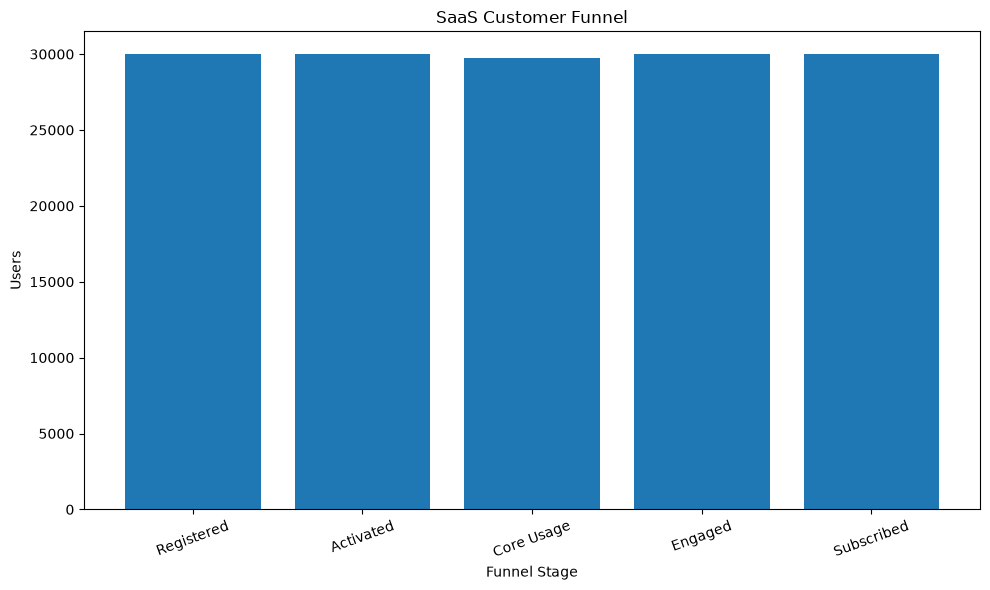

In [14]:
plt.figure(
    figsize=(10, 6)
)

plt.bar(
    funnel["stage"],
    funnel["users"],
)

plt.title(
    "SaaS Customer Funnel"
)

plt.xlabel(
    "Funnel Stage"
)

plt.ylabel(
    "Users"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

# Drop-Off Analysis

## 11. Funnel Drop-Off Analysis

Identifying where customers leave the funnel is more actionable than simply measuring the final conversion rate.

For every stage we calculate:

- Users entering the stage
- Users lost from the previous stage
- Percentage drop-off

In [15]:
funnel["users_lost"] = 0
funnel["dropoff_pct"] = 0.0

for i in range(1, len(funnel)):

    previous_users = funnel.loc[
        i - 1,
        "users"
    ]

    current_users = funnel.loc[
        i,
        "users"
    ]

    funnel.loc[
        i,
        "users_lost"
    ] = (
        previous_users
        - current_users
    )

    if previous_users > 0:

        funnel.loc[
            i,
            "dropoff_pct"
        ] = (
            (
                previous_users
                - current_users
            )
            / previous_users
            * 100
        )

display(funnel)

,stage,users,conversion_from_total_pct,stage_conversion_pct,users_lost,dropoff_pct
0,Registered,30000,100.00,NaN,0,0.00
1,Activated,29999,100.00,100.00,1,0.00
2,Core Usage,29743,99.14,99.15,256,0.85
3,Engaged,30000,100.00,100.86,-257,-0.86
4,Subscribed,30000,100.00,100.00,0,0.00


In [16]:
dropoff_analysis = funnel[
    [
        "stage",
        "users_lost",
        "dropoff_pct",
    ]
].copy()

display(
    dropoff_analysis
)

,stage,users_lost,dropoff_pct
0,Registered,0,0.00
1,Activated,1,0.00
2,Core Usage,256,0.85
3,Engaged,-257,-0.86
4,Subscribed,0,0.00


# Time to Activation

## 12. Time to Activation

The number of users who activate is important, but the time required to reach activation is also important.

A shorter time-to-activation can indicate a smoother onboarding experience.

We calculate:

- First event date
- First activation date
- Days to activation

In [17]:
first_user_event = (
    events
    .groupby("user_id")["event_datetime"]
    .min()
    .reset_index(
        name="first_event_datetime"
    )
)

if activation_events:

    first_activation = (
        events[
            events["event_type"].isin(
                activation_events
            )
        ]
        .groupby("user_id")[
            "event_datetime"
        ]
        .min()
        .reset_index(
            name="activation_datetime"
        )
    )

    activation_timing = (
        first_user_event.merge(
            first_activation,
            on="user_id",
            how="inner",
        )
    )

    activation_timing[
        "days_to_activation"
    ] = (
        (
            activation_timing[
                "activation_datetime"
            ]
            -
            activation_timing[
                "first_event_datetime"
            ]
        )
        .dt.total_seconds()
        / 86400
    )

    display(
        activation_timing[
            "days_to_activation"
        ].describe()
    )

else:

    activation_timing = pd.DataFrame()

    print(
        "No activation event was detected."
    )

count   29,999.00
mean        24.61
std         35.92
min          0.00
25%          0.00
50%         11.04
75%         34.71
max        863.62
Name: days_to_activation, dtype: float64

# Activation Timing Distribution

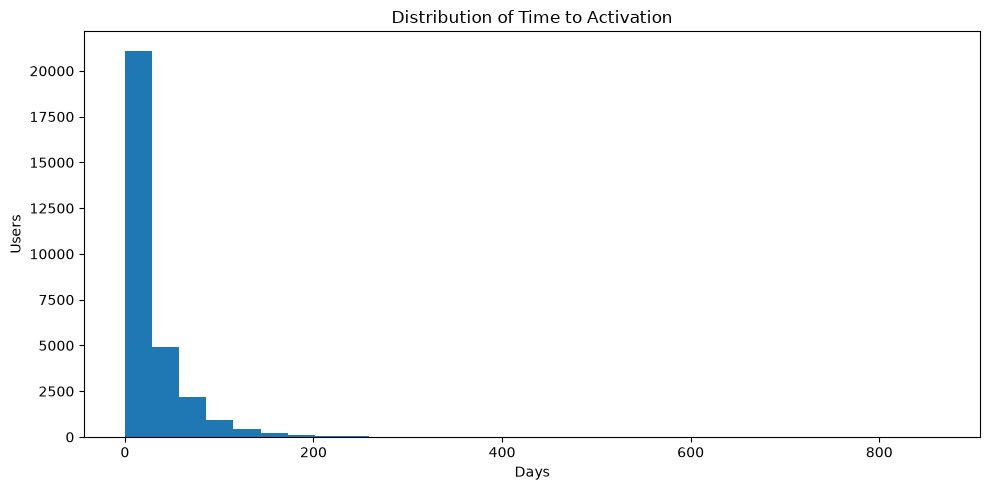

In [18]:
if not activation_timing.empty:

    plt.figure(
        figsize=(10, 5)
    )

    plt.hist(
        activation_timing[
            "days_to_activation"
        ].clip(
            lower=0
        ),
        bins=30,
    )

    plt.title(
        "Distribution of Time to Activation"
    )

    plt.xlabel(
        "Days"
    )

    plt.ylabel(
        "Users"
    )

    plt.tight_layout()

    plt.show()

# Funnel by Plan

## 13. Funnel Performance by Customer Plan

Different customer segments may behave differently throughout the funnel.

Where plan information is available, we compare funnel performance by plan.

In [19]:
if "plan" in users.columns:

    plan_users = users[
        [
            "user_id",
            "plan",
        ]
    ].drop_duplicates()

    activation_set = set(
        activation_users
    )

    core_usage_set = set(
        core_usage_users
    )

    engaged_set = set(
        engaged_users
    )

    subscribed_set = set(
        subscribed_users
    )

    plan_funnel_rows = []

    for plan, group in plan_users.groupby(
        "plan"
    ):

        plan_user_ids = set(
            group["user_id"]
        )

        total = len(
            plan_user_ids
        )

        activated = len(
            plan_user_ids
            & activation_set
        )

        core = len(
            plan_user_ids
            & core_usage_set
        )

        engaged = len(
            plan_user_ids
            & engaged_set
        )

        subscribed = len(
            plan_user_ids
            & subscribed_set
        )

        plan_funnel_rows.append(
            {
                "plan": plan,
                "users": total,
                "activated": activated,
                "core_usage": core,
                "engaged": engaged,
                "subscribed": subscribed,
            }
        )

    plan_funnel = pd.DataFrame(
        plan_funnel_rows
    )

    display(
        plan_funnel
    )

else:

    plan_funnel = pd.DataFrame()

    print(
        "Plan column not available."
    )

,plan,users,activated,core_usage,engaged,subscribed
0,Enterprise,2420,2420,2417,2420,2420
1,Free,11993,11992,11806,11993,11993
2,Professional,7271,7271,7267,7271,7271
3,Starter,8316,8316,8253,8316,8316


# Funnel Conversion by Plan

In [20]:
if not plan_funnel.empty:

    plan_funnel["activation_rate"] = (
        plan_funnel["activated"]
        / plan_funnel["users"]
        * 100
    )

    plan_funnel["core_usage_rate"] = (
        plan_funnel["core_usage"]
        / plan_funnel["users"]
        * 100
    )

    plan_funnel["engagement_rate"] = (
        plan_funnel["engaged"]
        / plan_funnel["users"]
        * 100
    )

    plan_funnel["subscription_rate"] = (
        plan_funnel["subscribed"]
        / plan_funnel["users"]
        * 100
    )

    display(
        plan_funnel
    )

,plan,users,activated,core_usage,engaged,subscribed,activation_rate,core_usage_rate,engagement_rate,subscription_rate
0,Enterprise,2420,2420,2417,2420,2420,100.00,99.88,100.00,100.00
1,Free,11993,11992,11806,11993,11993,99.99,98.44,100.00,100.00
2,Professional,7271,7271,7267,7271,7271,100.00,99.94,100.00,100.00
3,Starter,8316,8316,8253,8316,8316,100.00,99.24,100.00,100.00


# Funnel Insights

## 14. Funnel Analysis — Business Interpretation

The funnel analysis provides several important perspectives on SaaS growth.

### Activation

Activation measures whether new users reach meaningful product usage.

A low activation rate can indicate problems with:

- Onboarding
- Product discoverability
- Initial user experience
- Product-value communication

### Core Usage

The transition from activation to core product usage helps identify whether customers actually experience the main value proposition.

### Engagement

Repeated product activity is a stronger indicator of product dependency than one-time interaction.

### Subscription

Subscription conversion connects product behavior with commercial outcomes.

### Drop-Off

The largest funnel drop-off represents the stage where the business may have the greatest opportunity to improve conversion.

### Plan Differences

Differences between plans may indicate that:

- Higher-value customers behave differently
- Some plans have stronger activation
- Certain customer segments require different onboarding strategies

# Business Questions Connection

## 15. Connection to `business_questions.md`

This notebook should be interpreted as one analytical component of the broader business-question framework defined in:

`business_questions.md`

The funnel analysis contributes evidence toward questions involving:

- Customer acquisition
- Product activation
- Product adoption
- User engagement
- Subscription conversion
- Customer behavior
- Customer retention

The questions in `business_questions.md` remain the authoritative master list for the project.

New observations generated here should be added to the project's insights rather than creating a separate competing business-question framework.

# Key Findings

In [21]:
largest_dropoff = (
    funnel.iloc[1:]
    .sort_values(
        "dropoff_pct",
        ascending=False
    )
    .iloc[0]
)

print(
    "Largest funnel drop-off:"
)

print(
    f"Stage: {largest_dropoff['stage']}"
)

print(
    f"Users lost: {largest_dropoff['users_lost']:,}"
)

print(
    f"Drop-off rate: {largest_dropoff['dropoff_pct']:.2f}%"
)

Largest funnel drop-off:
Stage: Core Usage
Users lost: 256
Drop-off rate: 0.85%


## 16. Key Observations

The most important observations from the funnel should be interpreted using the actual results above.

### Observation 1 — Funnel Size

The registered user population establishes the maximum potential customer population.

### Observation 2 — Activation

The activation rate indicates how effectively users reach meaningful initial product usage.

### Observation 3 — Product Adoption

The core-usage stage identifies whether users progress beyond basic interaction.

### Observation 4 — Engagement

Repeated activity provides an early indicator of product dependency.

### Observation 5 — Commercial Conversion

Subscription conversion connects product engagement with revenue generation.

### Observation 6 — Drop-Off Opportunity

The largest stage-level drop-off represents an important potential optimization opportunity.

These observations will later be connected with retention and churn behavior.

# Conclusion

## 17. Conclusion

The funnel analysis moves the project from descriptive product usage toward customer-journey analysis.

The analysis covered:

- Funnel population
- Activation
- Core product usage
- Repeated engagement
- Subscription conversion
- Stage conversion
- Funnel drop-off
- Time to activation
- Plan-level funnel performance

The results provide a foundation for understanding where customers successfully progress through the SaaS journey and where potential friction occurs.

The next notebook will analyze whether customers remain active over time.

---

**Next Notebook:** `04_Retention_Cohort_Analysis.ipynb`